# Langgraph

- 랭그래프 핵심 개념
    - State: 그래프 실행 과정에서 지속적으로 유지되는 데이터로 각 노드가 실행될 때마다 읽고 쓸 수 있음
    - Node: 그래프의 기본 실행 단위. 각 노드는 특정 작업을 수행하는 함수나 에이전트를 나타냄
    - Edge: 노드 간의 연결을 정의하며, 실행 흐름을 제어함

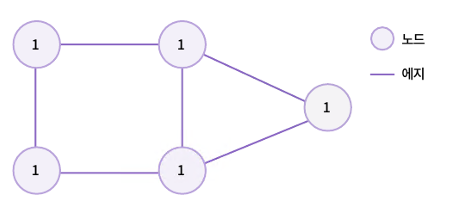

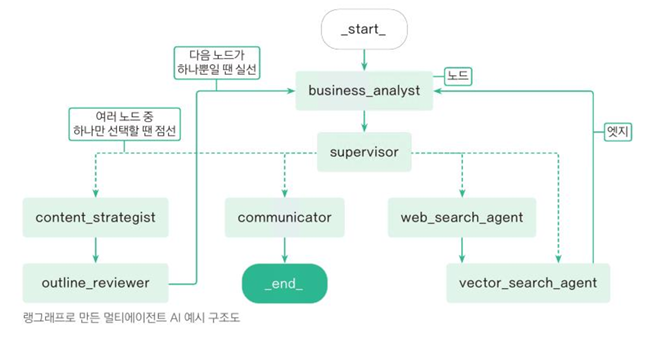

- 랭그래프는 데이터 흐름 기반 워크플로우를 만들기 위한 프레임워크
- 준비(설계) -> 컴파일(조립) -> 실행(invoke)

In [ ]:
from dotenv import load_dotenv

load_dotenv()

import os

## 1. 상태를 정의하기
- State 정의
- 이름이나, 대화내용 설정

## 2. 상태에 기반한 노드를 정의

## 3. 그래프 정의 및 노드 추가

## 4. 엣지 추가하기

## 5. 그래프 컴파일

## 6. 실행해보기

## 7. 정리

- **State** TypedDict 로 정의 → 노드끼리 데이터 주고받기
- **Node** 함수가 state 받아 일부 필드 dict 로 반환 → LangGraph 가 자동 병합
- **Edge** `add_edge(시작, 끝)` 로 흐름 연결
- `compile()` 후 `invoke()` 로 실행
- 그래프 시각화는 `draw_mermaid_png()`

## [실습] 고객지원 티켓 처리 그래프 만들기

이번 실습의 목표는 위에서 배운 **State → Node → Edge → compile → invoke** 흐름을 직접 코드로 구현하는 것입니다.

### Part A. 한 노드 그래프 만들기

1. `TypedDict` 로 `SupportTicketState` 를 정의하세요.
2. State 에 아래 필드를 넣으세요.
   - `customer_name`: 고객 이름
   - `order_id`: 주문번호
   - `issue_type`: 문의 유형
   - `greeting`: 첫 번째 노드가 채울 인사말
3. `make_greeting(state)` 노드를 만드세요.
   - `customer_name` 을 읽어서 `greeting` 을 생성합니다.
   - 예: `고객님, O-1001 문의를 접수했습니다.`
4. `StateGraph` 를 만들고 `START → greeter → END` 로 연결하세요.
5. `app.invoke()` 로 실행하고 결과 dict 를 출력하세요.

### Part B. 두 노드 연결하기

1. State 에 `ticket_summary` 필드를 추가하세요.
2. `make_ticket_summary(state)` 노드를 만드세요.
   - `order_id`, `issue_type` 을 사용해서 티켓 요약 문장을 생성합니다.
   - 예: `O-1001 주문의 배송 지연 문의입니다. 주문 상태 확인이 필요합니다.`
3. 그래프 흐름을 `START → greeter → summarizer → END` 로 연결하세요.
4. 실행 결과에서 `greeting`, `ticket_summary` 를 각각 출력하세요.
5. `display(Image(app.get_graph().draw_mermaid_png()))` 로 그래프 구조를 시각화하세요.

### 도전 과제

`next_action` 필드를 추가하고 `recommend_next_action(state)` 노드를 하나 더 연결해보세요.

- `issue_type == "배송 지연"` 이면 `배송 상태 조회 후 보상 가능 여부 확인`
- `issue_type == "환불"` 이면 `환불 정책 확인 후 환불 가능 금액 계산`
- 그 외에는 `담당자 확인 필요`

최종 흐름은 다음과 같습니다.

```text
START → greeter → summarizer → action_recommender → END
```
